In [6]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns 
from functions import *
import sys
sys.path.insert(0, "/home/kceniabougrova/Documents/GitHub/ibl-photometry/src")


df_good_BCW = pd.read_excel("/home/kceniabougrova/Downloads/good_sessions_outputs/df_good_BCW.xlsx")

i = 55
row = df_good_BCW.iloc[i]

In [7]:

# =========================================================
# Extract metadata
# =========================================================
subject = row['subject']
date = str(row['date'])[:10]
region = row['region']
fiber = row['fiber']
eid = row['eid']

print(f"📦 Session {i} — {subject} | {date} | {region} | {fiber} | {eid}")

📦 Session 55 — ZFM-04019 | 2022-06-07 | Region5G | probe11 | 5843ffbe-2367-4c69-a1f7-d69e5832f80d


In [8]:

# =========================================================
# Locate corresponding files in your folder
# =========================================================
BASE_DIR = "/home/kceniabougrova/Downloads/good_sessions_outputs/"

df_trials_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_trials_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

df_nph_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_nph_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

if not df_trials_file or not df_nph_file:
    print("⚠️ Missing one or both files in folder!")
else:
    df_trials_path = os.path.join(BASE_DIR, df_trials_file[0])
    df_nph_path = os.path.join(BASE_DIR, df_nph_file[0])

    print(f"✅ Found df_trials -> {df_trials_path}")
    print(f"✅ Found df_nph -> {df_nph_path}")

    # Load them
    df_trials = pd.read_csv(df_trials_path)
    df_nph = pd.read_csv(df_nph_path)

    print(f"df_trials shape: {df_trials.shape}")
    print(f"df_nph shape: {df_nph.shape}")

✅ Found df_trials -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_trials_171_ZFM-04019_2022-06-07_Region5G_5843ffbe-2367-4c69-a1f7-d69e5832f80d.csv
✅ Found df_nph -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_nph_171_ZFM-04019_2022-06-07_Region5G_5843ffbe-2367-4c69-a1f7-d69e5832f80d.csv
df_trials shape: (602, 29)
df_nph shape: (112913, 4)


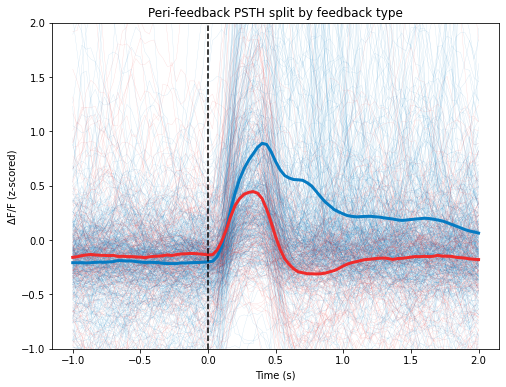

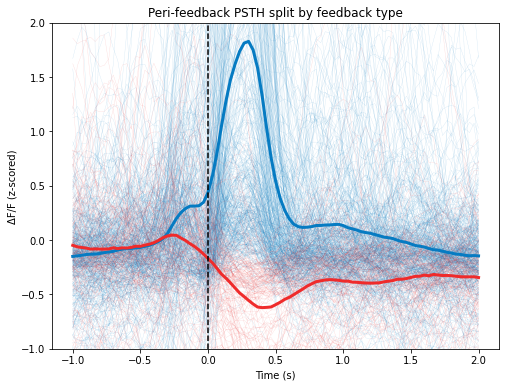

In [9]:

""" 
#########################################################################################
# =========================================================
# PLOT CORRECT VS INCORRECT ALIGNED TO EVENT
# change event and peri_event_window
# =========================================================
""" 
from functions import *

time_diffs = df_nph["times"].diff().dropna()
fs = 1/time_diffs.median()
fs

EVENT = "stimOnTrigger_times"
EVENTS = ["stimOnTrigger_times", "feedback_times"]

PERIEVENT_WINDOW = [-1, 2]

for event in EVENTS: 
    photometry_feedback, idx_psth = psth(
        calcium=df_nph.zdFF.values,
        times=df_nph.times.values,
        t_events=df_trials[event].values,
        fs=fs,
        peri_event_window=PERIEVENT_WINDOW
    )

    n_timepoints = photometry_feedback.shape[0]
    time_axis = np.linspace(PERIEVENT_WINDOW[0], PERIEVENT_WINDOW[1], n_timepoints)

    plt.figure(figsize=(8, 6))
    # Mask for correct vs incorrect/other
    mask_correct = df_trials.feedbackType.values == 1
    mask_incorrect = ~mask_correct
    # Plot trials separately
    plt.plot(time_axis, photometry_feedback[:, mask_correct], color='#067bc2', linewidth=0.3, alpha=0.2)
    plt.plot(time_axis, photometry_feedback[:, mask_incorrect], color='#ef2b2b', linewidth=0.3, alpha=0.2) 
    # --- Mean traces on top ---
    mean_correct = np.nanmean(photometry_feedback[:, mask_correct], axis=1)
    mean_incorrect = np.nanmean(photometry_feedback[:, mask_incorrect], axis=1)
    plt.plot(time_axis, mean_correct, color='#067bc2', linewidth=3, label="Correct (mean)")
    plt.plot(time_axis, mean_incorrect, color='#ef2b2b', linewidth=3, label="Incorrect (mean)")
    # Event marker
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Time (s)")
    plt.ylabel("ΔF/F (z-scored)")
    plt.title("Peri-feedback PSTH split by feedback type")
    plt.ylim(-1,2)
    plt.show()

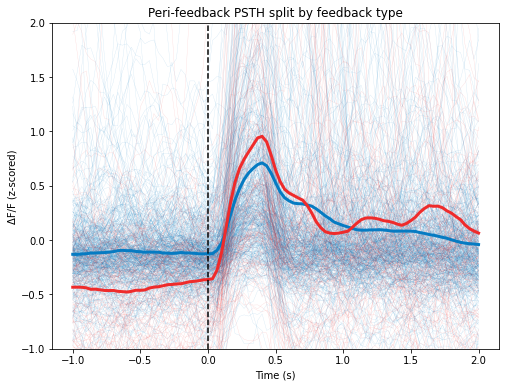

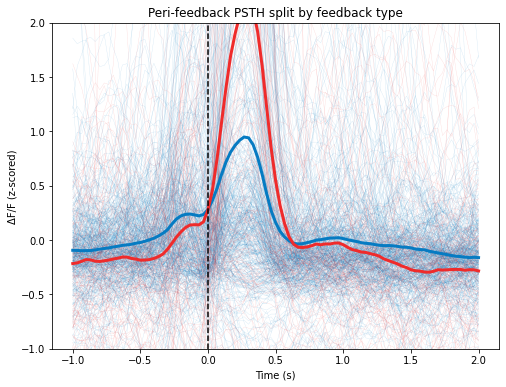

In [20]:
for event in EVENTS: 
    photometry_feedback, idx_psth = psth(
        calcium=df_nph.zdFF.values,
        times=df_nph.times.values,
        t_events=df_trials[event].values,
        fs=fs,
        peri_event_window=PERIEVENT_WINDOW
    )

    """ 
    PLOTTING QUIESCENCE TIME <0.7 AND >1 
    """
    n_timepoints = photometry_feedback.shape[0]
    time_axis = np.linspace(PERIEVENT_WINDOW[0], PERIEVENT_WINDOW[1], n_timepoints)

    plt.figure(figsize=(8, 6))
    # Mask for correct vs incorrect/other
    mask_correct = df_trials.quiescenceTime.values <0.7
    mask_incorrect = df_trials.quiescenceTime.values >1
    # Plot trials separately
    plt.plot(time_axis, photometry_feedback[:, mask_correct], color='#067bc2', linewidth=0.3, alpha=0.2)
    plt.plot(time_axis, photometry_feedback[:, mask_incorrect], color='#ef2b2b', linewidth=0.3, alpha=0.2) 
    # --- Mean traces on top ---
    mean_correct = np.nanmean(photometry_feedback[:, mask_correct], axis=1)
    mean_incorrect = np.nanmean(photometry_feedback[:, mask_incorrect], axis=1)
    plt.plot(time_axis, mean_correct, color='#067bc2', linewidth=3, label="Correct (mean)")
    plt.plot(time_axis, mean_incorrect, color='#ef2b2b', linewidth=3, label="Incorrect (mean)")
    # Event marker
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Time (s)")
    plt.ylabel("ΔF/F (z-scored)")
    plt.title("Peri-feedback PSTH split by feedback type")
    plt.ylim(-1,2)
    plt.show()

🎯 Found 5 contrast levels: [0.     0.0625 0.125  0.25   1.    ]


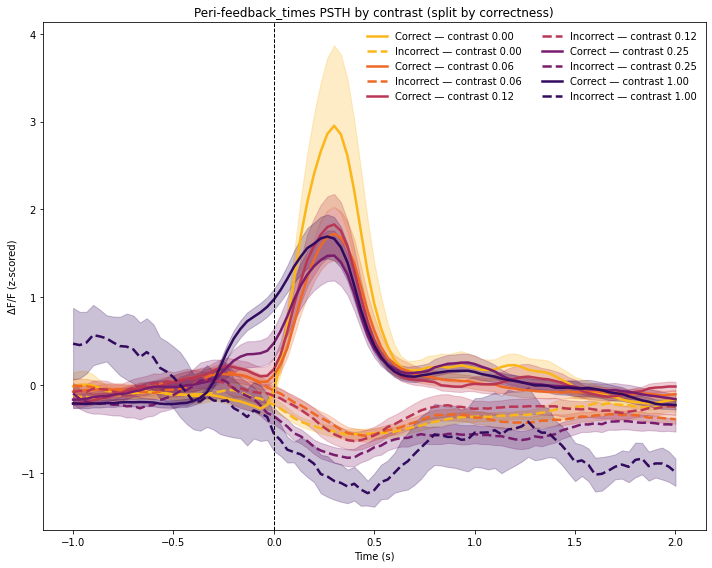

In [21]:

from functions import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# CONFIG
# =========================================================
EVENT = "stimOnTrigger_times"
EVENT = "feedback_times"
PERIEVENT_WINDOW = [-1, 2]
split_by_correct = True   # 👈 toggle here (True → split by correct/incorrect; False → average all)
palette = "inferno_r"      # try "viridis", "rocket", "crest", "coolwarm"

# =========================================================
# Compute sampling rate
# =========================================================
time_diffs = df_nph["times"].diff().dropna()
fs = 1 / time_diffs.median()

# =========================================================
# Build PSTH (peri-event calcium)
# =========================================================
photometry_feedback, idx_psth = psth(
    calcium=df_nph.zdFF.values,
    times=df_nph.times.values,
    t_events=df_trials[EVENT].values,
    fs=fs,
    peri_event_window=PERIEVENT_WINDOW
)

n_timepoints = photometry_feedback.shape[0]
time_axis = np.linspace(PERIEVENT_WINDOW[0], PERIEVENT_WINDOW[1], n_timepoints)

# =========================================================
# SPLIT BY CONTRAST LEVELS
# =========================================================
unique_contrasts = np.sort(df_trials["allContrasts"].dropna().unique())
print(f"🎯 Found {len(unique_contrasts)} contrast levels: {unique_contrasts}")

# Define color palette
colors = sns.color_palette(palette, len(unique_contrasts))

plt.figure(figsize=(10, 8))

for i, contrast in enumerate(unique_contrasts):
    mask_contrast = df_trials["allContrasts"] == contrast

    if split_by_correct:
        subsets = {
            "Correct": df_trials["feedbackType"] == 1,
            "Incorrect": df_trials["feedbackType"] != 1
        }
    else:
        subsets = {"All trials": np.ones(len(df_trials), dtype=bool)}

    for label, mask_fb in subsets.items():
        mask = mask_contrast & mask_fb

        if mask.sum() < 3:
            continue  # skip if too few trials

        data = photometry_feedback[:, mask]
        mean_trace = np.nanmean(data, axis=1)
        sem_trace = np.nanstd(data, axis=1) / np.sqrt(np.sum(mask))

        linestyle = '-' if label == "Correct" else '--'
        alpha = 1.0 if label == "Correct" else 0.8

        # --- Plot with SEM shading
        plt.plot(time_axis, mean_trace, color=colors[i],
                 linestyle=linestyle, linewidth=2.5,
                 label=f"{label} — contrast {contrast:.2f}")
        plt.fill_between(time_axis,
                         mean_trace - sem_trace,
                         mean_trace + sem_trace,
                         color=colors[i], alpha=0.25)

# =========================================================
# FINAL FORMATTING
# =========================================================
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("ΔF/F (z-scored)")
title_suffix = "split by correctness" if split_by_correct else "all trials combined"
plt.title(f"Peri-{EVENT} PSTH by contrast ({title_suffix})")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
# plt.ylim(-1.5, 3)
plt.show()


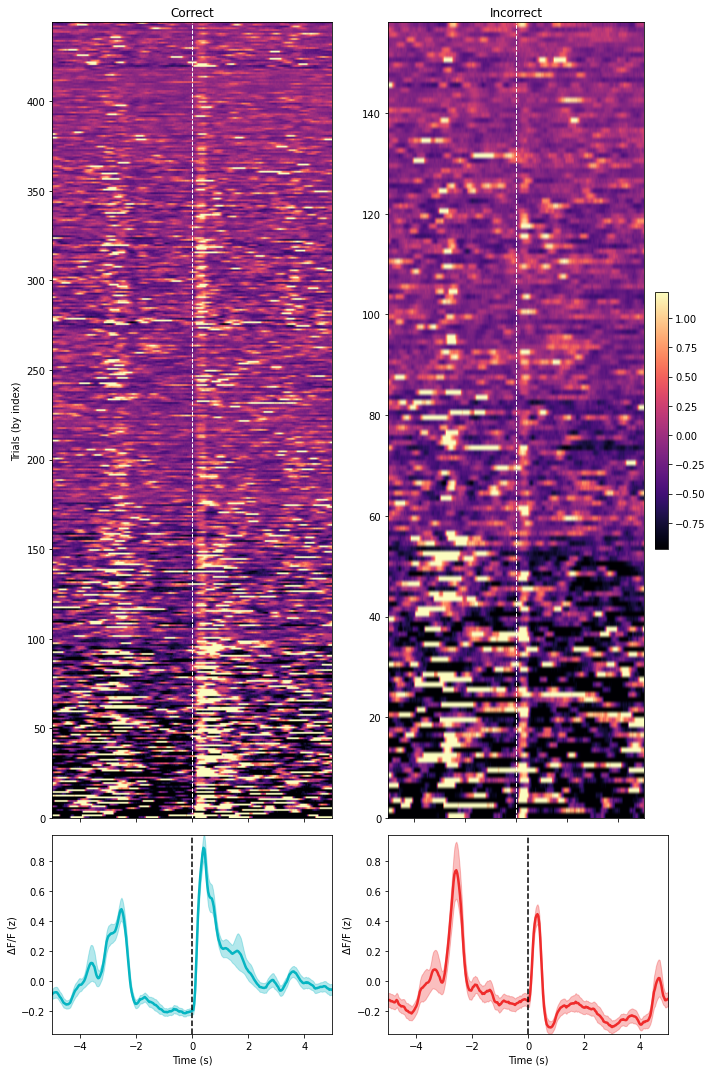

In [24]:

"""
#########################################################################################
# =========================================================
# HEATMAPS aligned to feedback_times — split by feedbackType
# Trials sorted by index; PSTHs share y-axis
# =========================================================
"""
from functions import *
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
EVENT = "stimOnTrigger_times"
PERIEVENT_WINDOW = [-5, 5]

# =========================================================
# Compute sampling rate
# =========================================================
time_diffs = df_nph["times"].diff().dropna()
fs = 1 / time_diffs.median()

# =========================================================
# Build peri-event ΔF/F matrix
# =========================================================
photometry_feedback, idx_psth = psth(
    calcium=df_nph.zdFF.values,
    times=df_nph.times.values,
    t_events=df_trials[EVENT].dropna().values,
    fs=fs,
    peri_event_window=PERIEVENT_WINDOW
)

n_timepoints, n_trials = photometry_feedback.shape
time_axis = np.linspace(PERIEVENT_WINDOW[0], PERIEVENT_WINDOW[1], n_timepoints)

# =========================================================
# Split trials by correctness
# =========================================================
mask_correct = df_trials["feedbackType"].values == 1
mask_incorrect = ~mask_correct

data_correct = photometry_feedback[:, mask_correct]
data_incorrect = photometry_feedback[:, mask_incorrect]

# =========================================================
# Sort trials by their index (earliest → latest)
# =========================================================
sorted_correct = data_correct[:, np.argsort(np.arange(data_correct.shape[1]))]
sorted_incorrect = data_incorrect[:, np.argsort(np.arange(data_incorrect.shape[1]))]

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 15),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True
)

# Common vmin/vmax for consistent color scale
vmin = np.nanpercentile(photometry_feedback, 5)
vmax = np.nanpercentile(photometry_feedback, 95)

# =========================================================
# HEATMAP — Correct
# =========================================================
axes[0, 0].imshow(
    sorted_correct.T, aspect='auto', origin='lower',
    extent=[time_axis[0], time_axis[-1], 0, sorted_correct.shape[1]],
    cmap='magma', vmin=vmin, vmax=vmax
)
axes[0, 0].axvline(0, color='w', linestyle='--', linewidth=1)
axes[0, 0].set_ylabel("Trials (by index)")
axes[0, 0].set_title("Correct")

# =========================================================
# HEATMAP — Incorrect
# =========================================================
im = axes[0, 1].imshow(
    sorted_incorrect.T, aspect='auto', origin='lower',
    extent=[time_axis[0], time_axis[-1], 0, sorted_incorrect.shape[1]],
    cmap='magma', vmin=vmin, vmax=vmax
)
axes[0, 1].axvline(0, color='w', linestyle='--', linewidth=1)
axes[0, 1].set_title("Incorrect")
axes[0, 1].set_ylabel("")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# =========================================================
# PSTH (mean ± SEM)
# =========================================================
mean_c = np.nanmean(sorted_correct, axis=1)
sem_c = np.nanstd(sorted_correct, axis=1) / np.sqrt(sorted_correct.shape[1])
mean_i = np.nanmean(sorted_incorrect, axis=1)
sem_i = np.nanstd(sorted_incorrect, axis=1) / np.sqrt(sorted_incorrect.shape[1])

# --- Shared Y limits across PSTHs
ymin = min(np.nanmin(mean_c - sem_c), np.nanmin(mean_i - sem_i))
ymax = max(np.nanmax(mean_c + sem_c), np.nanmax(mean_i + sem_i))

# --- Correct
axes[1, 0].plot(time_axis, mean_c, color='#06b5c2', linewidth=2.5)
axes[1, 0].fill_between(time_axis, mean_c - sem_c, mean_c + sem_c,
                        color='#06b5c2', alpha=0.3)
axes[1, 0].axvline(0, color='k', linestyle='--')
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("ΔF/F (z)")
axes[1, 0].set_ylim(ymin, ymax)

# --- Incorrect
axes[1, 1].plot(time_axis, mean_i, color='#ef2b2b', linewidth=2.5)
axes[1, 1].fill_between(time_axis, mean_i - sem_i, mean_i + sem_i,
                        color='#ef2b2b', alpha=0.3)
axes[1, 1].axvline(0, color='k', linestyle='--')
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("ΔF/F (z)")
axes[1, 1].set_ylim(ymin, ymax)

# =========================================================
# FINALIZE
# =========================================================
plt.tight_layout()
plt.show()







In [25]:
# ========================================================
# 1 - Define all event time intervals per trial
# ========================================================
import numpy as np
import pandas as pd

# --- Compute event-based time windows ---
df_intervals = pd.DataFrame()
df_intervals["trial_idx"] = df_trials.index

# A. Quiescence: stimOn - 0.4 → stimOn
df_intervals["quiescence_start"] = df_trials["stimOnTrigger_times"] - 0.4
df_intervals["quiescence_end"]   = df_trials["stimOnTrigger_times"]

# B. StimOn: stimOn → stimOn + 0.1
df_intervals["stim_start"] = df_trials["stimOnTrigger_times"]
df_intervals["stim_end"]   = df_trials["stimOnTrigger_times"] + 0.1

# C. Feedback: feedback → feedback + 0.5, normalized to baseline (-0.1 → 0)
df_intervals["feedback_start"] = df_trials["feedback_times"]
df_intervals["feedback_end"]   = df_trials["feedback_times"] + 0.5
df_intervals["feedback_baseline_start"] = df_trials["feedback_times"] - 0.1
df_intervals["feedback_baseline_end"]   = df_trials["feedback_times"]


In [26]:
# ========================================================
# 2 - Extract zdFF segments per trial per window
# ========================================================
def extract_mean(df_nph, start_times, end_times):
    """Return per-trial mean zdFF between start and end times."""
    means = []
    for t0, t1 in zip(start_times, end_times):
        mask = (df_nph["times"] >= t0) & (df_nph["times"] <= t1)
        means.append(df_nph.loc[mask, "zdFF"].mean())
    return np.array(means)

In [27]:
# Now apply to each interval:
# A. Quiescence mean
df_intervals["quiescence_mean"] = extract_mean(
    df_nph, df_intervals["quiescence_start"], df_intervals["quiescence_end"])

# B. StimOn slope (0–0.1s)
stim_slopes = []
for t0, t1 in zip(df_intervals["stim_start"], df_intervals["stim_end"]):
    mask = (df_nph["times"] >= t0) & (df_nph["times"] <= t1)
    segment = df_nph.loc[mask, "zdFF"].values
    if len(segment) >= 2:
        slope = (segment[-1] - segment[0]) / (t1 - t0)
    else:
        slope = np.nan
    stim_slopes.append(slope)

df_intervals["stim_slope"] = stim_slopes

# C. Feedback normalized mean
fb_baseline = extract_mean(df_nph,
                           df_intervals["feedback_baseline_start"],
                           df_intervals["feedback_baseline_end"])
fb_response = extract_mean(df_nph,
                           df_intervals["feedback_start"],
                           df_intervals["feedback_end"])
df_intervals["feedback_norm_mean"] = fb_response - fb_baseline

In [28]:
# ========================================================
# 3 - Combine into a per-trial summary
# ========================================================
df_summary = df_trials.copy()
df_summary["quiescence_mean_zdFF"] = df_intervals["quiescence_mean"]
df_summary["stimOn_slope"] = df_intervals["stim_slope"]
df_summary["feedback_norm_mean"] = df_intervals["feedback_norm_mean"]

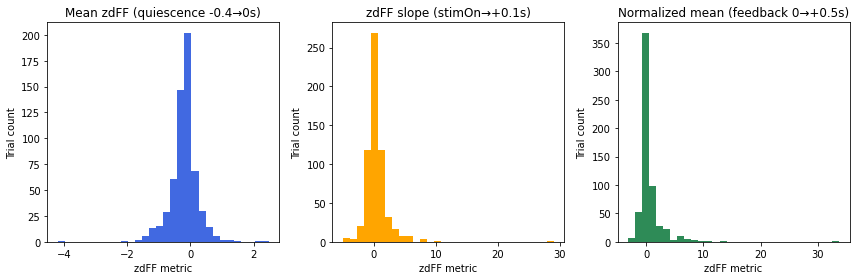

In [29]:
# ========================================================
# 4 - Visualize the relationships
# ========================================================
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].hist(df_summary["quiescence_mean_zdFF"], bins=30, color="royalblue")
axs[0].set_title("Mean zdFF (quiescence -0.4→0s)")

axs[1].hist(df_summary["stimOn_slope"], bins=30, color="orange")
axs[1].set_title("zdFF slope (stimOn→+0.1s)")

axs[2].hist(df_summary["feedback_norm_mean"], bins=30, color="seagreen")
axs[2].set_title("Normalized mean (feedback 0→+0.5s)")

for ax in axs: ax.set_xlabel("zdFF metric"); ax.set_ylabel("Trial count")
plt.tight_layout()
plt.show()


In [33]:
# ========================================================
# 5 - Select/build the predictors
# ========================================================
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, StandardScaler


# =========================================================
    # 1. FILTER: unbiased & valid-choice trials
    # =========================================================
df_trials = df_summary.copy()
df_pred = df_trials.copy()

df_pred = df_pred[df_pred["probabilityLeft"] == 0.5]
df_pred = df_pred[df_pred["choice"] != 0].reset_index(drop=True)

# =========================================================
    # 2. DERIVED COLUMNS
    # =========================================================

# (A) current stimSide: sign of allSContrasts → -1 (ipsilateral) / +1 (contralateral)
    # =========================================================
    # Define stimSide from contrastLeft and contrastRight
    # =========================================================
def get_stim_side(row):
    if pd.notna(row["contrastLeft"]) and pd.isna(row["contrastRight"]):
        return -1  # left stimulus only
    elif pd.notna(row["contrastRight"]) and pd.isna(row["contrastLeft"]):
        return 1   # right stimulus only
    else:
        return np.nan  # ambiguous (both present or both NaN)

df_pred["stimSide"] = df_pred.apply(get_stim_side, axis=1)

# (B) previous choice
df_pred["prev_choice"] = df_pred["choice"].shift(1)

# (C) previous feedback outcome
df_pred["prev_feedbackType"] = df_pred["feedbackType"].shift(1)

# remove first trial (no previous)
df_pred = df_pred.dropna(subset=["prev_choice", "prev_feedbackType"]).reset_index(drop=True) 

df_pred

,included,stimOffTrigger_times,allContrasts,allSContrasts,stimOnTrigger_times,goCueTrigger_times,quiescencePeriod,stimOff_times,goCue_times,response_times,...,responseTime,quiescenceTime,trialTime,trialNumber,quiescence_mean_zdFF,stimOn_slope,feedback_norm_mean,stimSide,prev_choice,prev_feedbackType
0,True,10.930500,0.2500,0.2500,9.587100,9.633500,0.443177,10.982600,9.661000,9.930500,...,0.3434,1.6411,3.536602,2,2.480665,29.060904,1.129082,1,-1.0,1.0
1,True,19.393299,1.0000,-1.0000,16.928199,16.983999,0.602375,19.433799,17.014899,18.393299,...,1.4651,4.7994,7.805003,3,-1.184003,5.166822,9.585676,-1,-1.0,1.0
2,True,24.086400,0.0625,0.0625,22.407400,22.449500,0.549606,24.132900,22.476600,23.086400,...,0.6790,1.8073,4.032802,4,-2.177402,-0.427818,4.552247,1,1.0,1.0
3,True,28.218099,0.0625,-0.0625,25.877399,25.933799,0.593102,28.265999,25.961999,26.217999,...,0.3406,0.5933,3.481903,5,-1.550166,8.282430,-3.139782,-1,-1.0,1.0
4,True,35.734699,1.0000,-1.0000,31.080099,31.133399,0.648275,35.782599,31.165699,33.734599,...,2.6545,1.6720,6.874503,6,-1.382351,3.773847,-1.105108,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,True,452.582999,1.0000,1.0000,451.208399,451.274799,0.410308,452.624499,451.303299,451.582999,...,0.3746,0.4748,2.390903,86,-1.398656,1.654799,2.142183,1,1.0,1.0
85,True,455.742099,1.0000,1.0000,454.310699,454.373899,0.522365,455.807699,454.404699,454.742099,...,0.4314,0.5225,2.519503,87,-0.316813,1.522943,3.211292,1,-1.0,1.0
86,True,460.395999,0.0625,0.0625,457.906099,457.973999,0.428376,460.440399,458.002099,459.395999,...,1.4899,0.9356,3.969903,88,-0.485071,-2.109386,-0.467636,1,-1.0,1.0
87,True,464.409899,0.0625,0.0625,463.014199,463.074299,0.689691,464.456999,463.103699,463.409899,...,0.3957,1.4094,3.352203,89,-0.719793,2.418574,0.100467,1,-1.0,1.0


In [35]:
# Use MaxAbsScaler in all
cols_to_rescale_pm1 = ["allContrasts", "quiescenceTime", "quiescencePeriod", "reactionTime"]
df_pred[cols_to_rescale_pm1] = MaxAbsScaler().fit_transform(df_pred[cols_to_rescale_pm1])



In [36]:

# =========================================================
    # 4. KEEP ONLY THE DESIRED COLUMNS
    # =========================================================
df_predictors = df_pred[[
    "quiescenceTime",
    "quiescencePeriod",
    "stimSide",
    "allContrasts",
    "reactionTime",
    "choice",
    "feedbackType",
    "prev_choice",
    "prev_feedbackType"
]]

print("✅ Predictor matrix ready!")
print(df_predictors.head())

✅ Predictor matrix ready!
   quiescenceTime  quiescencePeriod  stimSide  allContrasts  reactionTime  \
0        0.291793          0.633664         1        0.2500      0.052540   
1        0.853348          0.861289        -1        1.0000      0.103304   
2        0.321343          0.785839         1        0.0625      0.149076   
3        0.105491          0.848031        -1        0.0625      0.042236   
4        0.297287          0.926919        -1        1.0000      0.744956   

   choice  feedbackType  prev_choice  prev_feedbackType  
0    -1.0           1.0         -1.0                1.0  
1     1.0           1.0         -1.0                1.0  
2    -1.0           1.0          1.0                1.0  
3    -1.0          -1.0         -1.0                1.0  
4    -1.0          -1.0         -1.0               -1.0  


In [42]:
# ========================================================
# 6 - Ridge regression 
# ========================================================

# =========================================================
    # 1. Choose the target
    # =========================================================
target = df_pred["quiescence_mean_zdFF"]   # or "stimOn_slope", "quiescence_mean_zdFF"
# target = df_pred["stimOn_slope"]   # or "stimOn_slope", "quiescence_mean_zdFF"
# target = df_pred["feedback_norm_mean"]   # or "stimOn_slope", "quiescence_mean_zdFF"


In [43]:

# =========================================================
    # 2. Create design matrix (X) and target (y)
    # =========================================================
import numpy as np
# from sklearn.preprocessing import StandardScaler

# Define predictors (your chosen behavioral variables)
predictor_cols = [
    "quiescenceTime",
    "quiescencePeriod",
    "stimSide",
    "allContrasts",
    "reactionTime",
    "choice",
    "feedbackType",
    "prev_choice",
    "prev_feedbackType"
]

X = df_predictors[predictor_cols].values
y = target.values

# Standardize predictors for better ridge behavior
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)

✅ R² score: 0.199


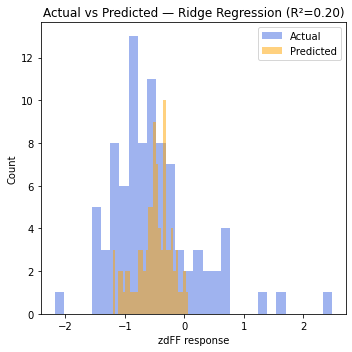

In [44]:

# =========================================================
    # 3. Fit Ridge regression model
    # =========================================================
from sklearn.linear_model import ridge_regression
from sklearn.metrics import r2_score

# Run ridge regression with regularization alpha
alpha = 1.0
coef = ridge_regression(X_scaled, y, alpha=alpha)

# Predict values
y_pred = X_scaled @ coef
r2 = r2_score(y, y_pred)

print(f"✅ R² score: {r2:.3f}")

# =========================================================
    # 4. a) Plot results
    # =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.hist(y, bins=30, alpha=0.5, label="Actual", color="royalblue")
plt.hist(y_pred, bins=30, alpha=0.5, label="Predicted", color="orange")
plt.xlabel("zdFF response")
plt.ylabel("Count")
plt.title(f"Actual vs Predicted — Ridge Regression (R²={r2:.2f})")
plt.legend()
plt.tight_layout()
plt.show()


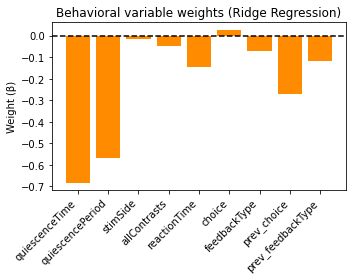

In [45]:


# =========================================================
    # 4. b) Plot Coefficients (Weights) 
    # =========================================================
plt.figure(figsize=(5,4))
plt.bar(predictor_cols, coef, color="darkorange")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Weight (β)")
plt.title("Behavioral variable weights (Ridge Regression)")
plt.axhline(0, color="k", linestyle="--")
plt.tight_layout()
plt.show()
